# rational M2 design spike

The **independent leg** of the `rational` engine's M2 (`PLAN.md` section 6):
this notebook re-derives the L-th-band (Nyquist) stage designs in numpy from
the same published math the shipping C++ uses (`tap::dsp::design_nyquist`,
DspTap `nyquist.h`: Mintzer 1982, Vaidyanathan §4.6, the Kaiser window and
its fit from `kaiser.h`), finds the minimal length per (band, profile) by the
family criterion, measures each design, and cross-checks one stage end to end
through **scipy's `upfirdn`** polyphase engine — an implementation we did not
write. The numbers it pins are committed to `PLAN.md` §2.3 and §6 (the M2
table) and enforced in CI by `tests/test_design.cpp` against the shipping
headers (`include/tap/sr/rational/design.h`).

Design rules (`PLAN.md` R2, R4, R5; `design.h`):

- a stage at ratio L/M is **one** Nyquist filter of band B = max(L, M) at the
  composite rate L · f_in, cutoff at the lower rate's Nyquist: length
  N = 2mB − 1, centre tap exactly 1, every B-th tap from it exactly 0, every
  polyphase branch at DC gain 1;
- profiles as (A, p = f_pass / r_min): `super_economy` 70 dB at 1/3,
  `economy` 70 dB at 3/8 (the default), `balanced` 70 dB at 19/48,
  `transparent` 120 dB at 5/12 — `bridge`'s 16 / 18 / 19 / 20 kHz at 48 kHz;
- the stopband edge is r − f_pass at the stage's lower rate r (the
  structure's symmetric transition, the coverage rule 2.1(a) with equality);
- **the pin:** the smallest m whose worst stopband response on a
  **16384-point grid** from the stopband edge to F_hi / 2 is ≤ −(A + 1 dB).
  The grid is stated because it matters: the 1024-point default of
  `search_nyquist_m` steps over a sidelobe of the 8th-band `transparent`
  design (−121.7 dB on 1024 points, −119.3 dB on 8192), which is why DspTap's
  search took a `grid_points` parameter (tap/DspTap#50); 16384 agrees with
  65536 within 0.003 dB for every design here.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import figure_digest  # prints a data digest per figure (A/B gates)
figure_digest.install()
from scipy import signal

def kaiser_beta(atten_db):
    # Kaiser's published empirical fit (tap/dsp/kaiser.h kaiser_beta)
    if atten_db > 50.0:
        return 0.1102 * (atten_db - 8.7)
    if atten_db > 21.0:
        return 0.5842 * (atten_db - 21.0) ** 0.4 + 0.07886 * (atten_db - 21.0)
    return 0.0

def design_nyquist(band, m, beta):
    # Mirrors tap::dsp::design_nyquist: Kaiser-windowed sinc with cutoff
    # exactly pi / band, length 2 m band - 1, the centre written as exactly
    # 1 and the structural zeros as exactly 0, every polyphase branch
    # normalized to DC gain 1 (the whole sums to band).
    n = 2 * m * band - 1
    c = (n - 1) // 2
    i = np.arange(n)
    u = (i - c) / c
    w = np.i0(beta * np.sqrt(np.maximum(0.0, 1.0 - u * u))) / np.i0(beta)
    h = np.sinc((i - c) / band) / band * w
    h[c] = 1.0
    zeros = (i != c) & ((i - c) % band == 0)
    h[zeros] = 0.0
    for j in range(band):
        if j == c % band:
            continue
        sel = (i % band) == j
        h[sel] /= h[sel].sum()
    return h

def response_db(h, band, f_norm, chunk=256):
    # Magnitude in dB, 0 dB at DC, at f_norm = f / F_hi (the filter's own rate).
    m = np.arange(len(h))
    out = np.empty(len(f_norm))
    for k in range(0, len(f_norm), chunk):
        f = np.asarray(f_norm[k:k + chunk])[:, None]
        e = np.exp(-2j * np.pi * f * m[None, :])
        out[k:k + chunk] = 20 * np.log10(np.maximum(np.abs(e @ h) / band, 1e-300))
    return out

GRID = 16384
def worst_stopband_db(h, band, p, grid=GRID):
    f_stop = (1.0 - p) / band
    f = f_stop + (0.5 - f_stop) * np.arange(grid) / (grid - 1)
    return response_db(h, band, f).max()

def passband_ripple_db(h, band, p, points=4000):
    f = (p / band) * np.arange(points + 1) / points
    return np.abs(response_db(h, band, f)).max()

def search_m(band, p, atten, margin=1.0, max_m=256, grid=GRID):
    beta = kaiser_beta(atten)
    for m in range(1, max_m + 1):
        if worst_stopband_db(design_nyquist(band, m, beta), band, p, grid) <= -(atten + margin):
            return m
    return 0

PROFILES = [  # name, A (dB), p = f_pass / r_min
    ("super_economy", 70.0, 1.0 / 3.0),
    ("economy",       70.0, 3.0 / 8.0),
    ("balanced",      70.0, 19.0 / 48.0),
    ("transparent",  120.0, 5.0 / 12.0),
]
BANDS = [2, 3, 4, 6, 8]  # the single-stage vocabulary's bands; 4 serves 4/3 and 3/4 (no single by-4 stage, R3)


## The pinned geometries: N per (band, profile)

For each band and profile: search m on the 16384-point grid, measure the
worst stopband and the passband ripple of the pinned design, and confirm the
pin is *minimal* (m − 1 misses the margin). The table is the plan's M2 table;
`test_design.cpp` pins every row against the shipping `design_stage`.


In [2]:
designs = {}
rows = []
for band in BANDS:
    for name, atten, p in PROFILES:
        m = search_m(band, p, atten)
        h = design_nyquist(band, m, kaiser_beta(atten))
        worst = worst_stopband_db(h, band, p)
        worst_fine = worst_stopband_db(h, band, p, 65536)
        ripple = passband_ripple_db(h, band, p)
        prev = worst_stopband_db(design_nyquist(band, m - 1, kaiser_beta(atten)), band, p)
        assert worst <= -(atten + 1.0), (band, name)
        assert prev > -(atten + 1.0), (band, name, "m not minimal")
        assert abs(worst - worst_fine) < 0.01, (band, name, "grid not converged")
        assert h[(len(h) - 1) // 2] == 1.0 and len(h) == 2 * m * band - 1
        nonzero = int(np.count_nonzero(h))
        assert nonzero == 2 * m * (band - 1) + 1
        designs[(band, name)] = (h, m, atten, p)
        rows.append((band, name, m, len(h), nonzero, worst, prev, ripple, (len(h) - 1) // 2))

hdr = f"{'band':>4s} {'profile':13s} {'m':>3s} {'N':>4s} {'nonzero':>7s} {'worst stop':>10s} {'m-1 worst':>9s} {'ripple':>10s} {'delay@F_hi':>10s}"
print(hdr); print('-' * len(hdr))
for band, name, m, n, nz, worst, prev, ripple, gd in rows:
    print(f"{band:4d} {name:13s} {m:3d} {n:4d} {nz:7d} {worst:8.2f}dB {prev:7.2f}dB ±{ripple:.6f}dB {gd:10d}")


band profile         m    N nonzero worst stop m-1 worst     ripple delay@F_hi
------------------------------------------------------------------------------
   2 super_economy   9   35      19   -72.78dB  -69.60dB ±0.001995dB         17
   2 economy        11   43      23   -71.92dB  -68.59dB ±0.002203dB         21
   2 balanced       13   51      27   -71.52dB  -68.32dB ±0.002307dB         25
   2 transparent    31  123      63  -121.67dB -120.95dB ±0.000007dB         61
   3 super_economy   8   47      33   -71.21dB  -67.47dB ±0.002503dB         23
   3 economy        11   65      45   -71.33dB  -68.64dB ±0.002346dB         32
   3 balanced       13   77      53   -71.17dB  -68.86dB ±0.002418dB         38
   3 transparent    25  149     101  -121.13dB -119.73dB ±0.000008dB         74
   4 super_economy   8   63      49   -71.39dB  -67.80dB ±0.002167dB         31
   4 economy        11   87      67   -71.10dB  -69.12dB ±0.002431dB         43
   4 balanced       14  111      85   -72.

## The mixed ratios: taps per phase

A mixed stage (L, M > 1) is the band-B = max(L, M) design above, driven as an
L-phase polyphase filter at the composite rate (R2): T = ⌈N / L⌉ taps per
phase, the last phase zero-padded. 3/2 and 2/3 share the third-band design,
4/3 and 3/4 the 4th-band, 8/3 and 3/8 the 8th-band; the MACs per output of a
mixed stage are T (every phase visited once per L outputs).


In [3]:
MIXED = [(3, 2), (2, 3), (4, 3), (3, 4), (8, 3), (3, 8)]
print(f"{'ratio':6s}" + "".join(f"{name:>16s}" for name, _, _ in PROFILES))
for L, M in MIXED:
    band = max(L, M)
    cells = []
    for name, atten, p in PROFILES:
        h, m, _, _ = designs[(band, name)]
        T = -(-len(h) // L)
        cells.append(f"N={len(h):3d} T={T:3d}")
    print(f"{L}/{M:<4d}" + "".join(f"{c:>16s}" for c in cells))


ratio    super_economy         economy        balanced     transparent
3/2        N= 47 T= 16     N= 65 T= 22     N= 77 T= 26     N=149 T= 50
2/3        N= 47 T= 24     N= 65 T= 33     N= 77 T= 39     N=149 T= 75
4/3        N= 63 T= 16     N= 87 T= 22     N=111 T= 28     N=199 T= 50
3/4        N= 63 T= 21     N= 87 T= 29     N=111 T= 37     N=199 T= 67
8/3        N=127 T= 16     N=191 T= 24     N=223 T= 28     N=399 T= 50
3/8        N=127 T= 43     N=191 T= 64     N=223 T= 75     N=399 T=133


## Responses

Every pinned design at `economy` and `transparent`, with the spec line, the
passband edge and the stopband edge of the stage's lower rate.


[ figure ] digest 626810f4bc778dc2 (40 arrays)


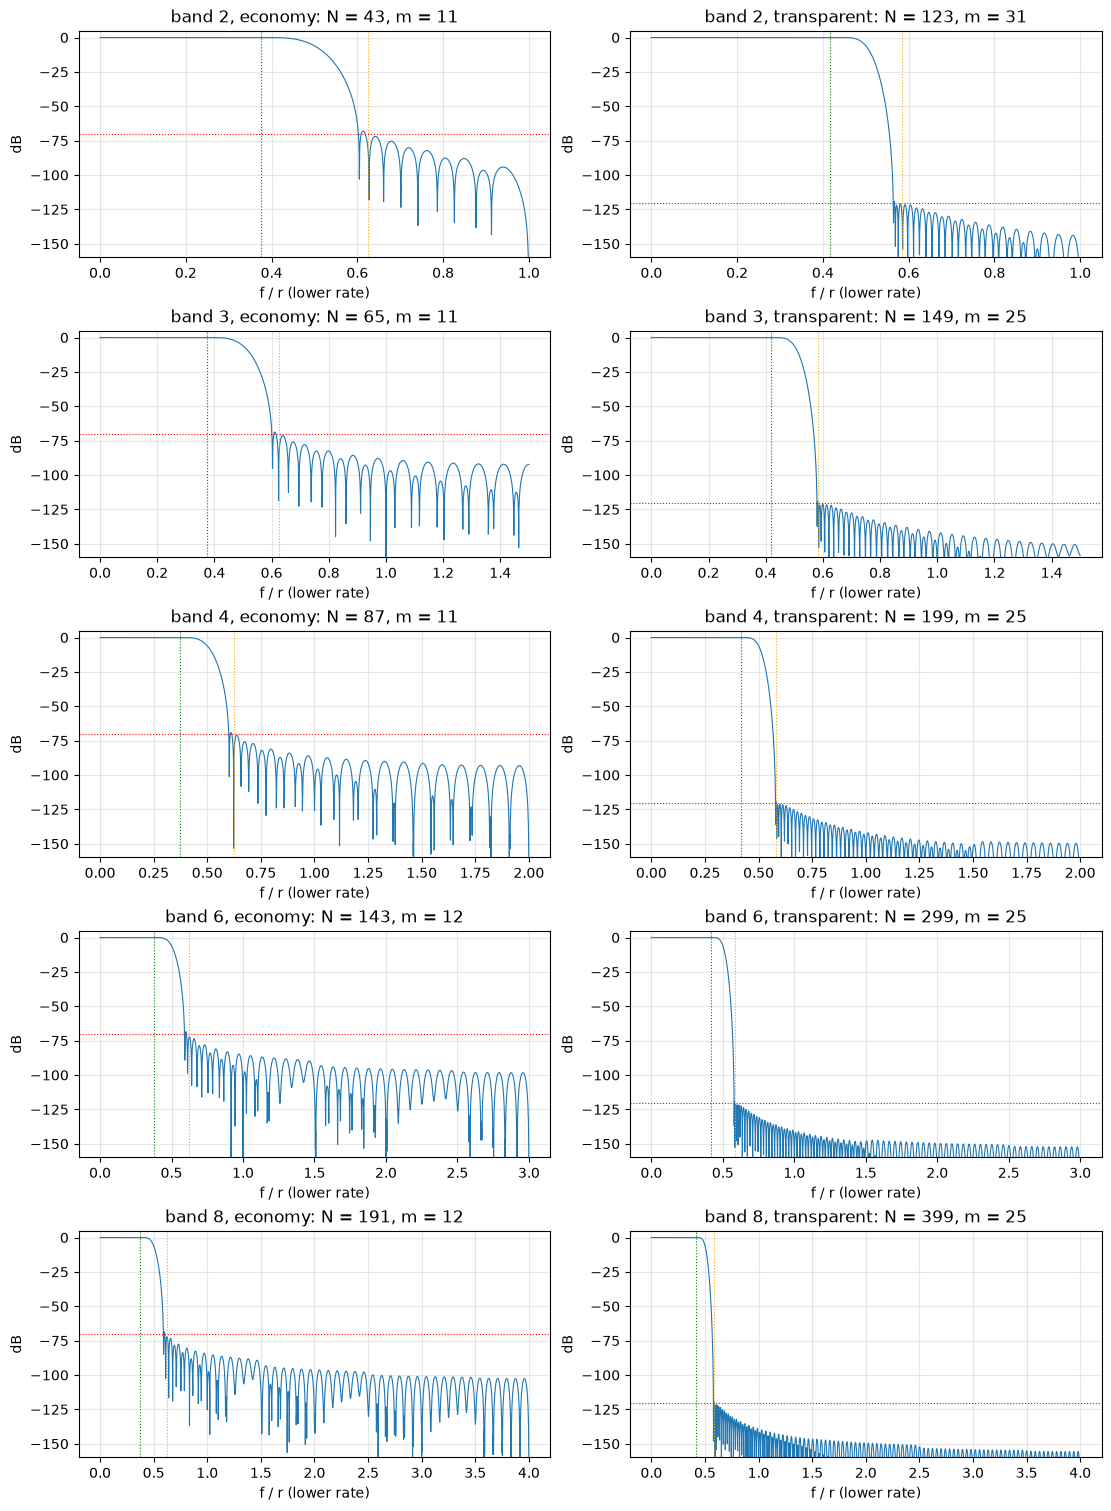

In [4]:
fig, axes = plt.subplots(5, 2, figsize=(11, 15), constrained_layout=True)
for row, band in enumerate(BANDS):
    for col, name in enumerate(("economy", "transparent")):
        h, m, atten, p = designs[(band, name)]
        ax = axes[row, col]
        f = np.linspace(0.0, 0.5, 4000)
        ax.plot(f * band, response_db(h, band, f), lw=0.8)  # x in units of the lower rate r
        ax.axhline(-atten, color='r', ls=':', lw=0.8)
        ax.axvline(p, color='g', ls=':', lw=0.8)
        ax.axvline(1.0 - p, color='orange', ls=':', lw=0.8)
        ax.set_title(f"band {band}, {name}: N = {len(h)}, m = {m}")
        ax.set_xlabel("f / r (lower rate)"); ax.set_ylabel("dB")
        ax.set_ylim(-160, 5); ax.grid(alpha=0.3)
plt.show()


## Independent end-to-end check: scipy `upfirdn`

The `economy` half-band as a decimator by 2 (the design is rate-free; take
48 → 24 kHz, so r = 24 kHz, f_pass = 9 kHz and the stopband edge r − f_pass
= 15 kHz) on a tone battery through `scipy.signal.upfirdn` with our
coefficients, divided by the band as `nyquist.h`'s gain convention says a
decimator does. Two tones sit in the passband and one just above the
stopband edge, where the design is weakest; its alias folds to r − f and
must land at or below −(70 + 1) dB relative to the tone. Tones are placed on
bin centres so the Blackman window's scalloping does not enter the levels.


passband tone at    996.7 Hz:  -10.457 dBFS (source -10.458; ripple <= 0.0022 dB)
passband tone at   7200.4 Hz:  -10.457 dBFS (source -10.458; ripple <= 0.0022 dB)
stopband tone at 15360.0 Hz aliases to  8640.0 Hz at   -72.06 dB (spec -70 dB, margin 1 dB)
worst other spur      :   -136.7 dBFS
[ figure ] digest 94e3553328009867 (4 arrays)


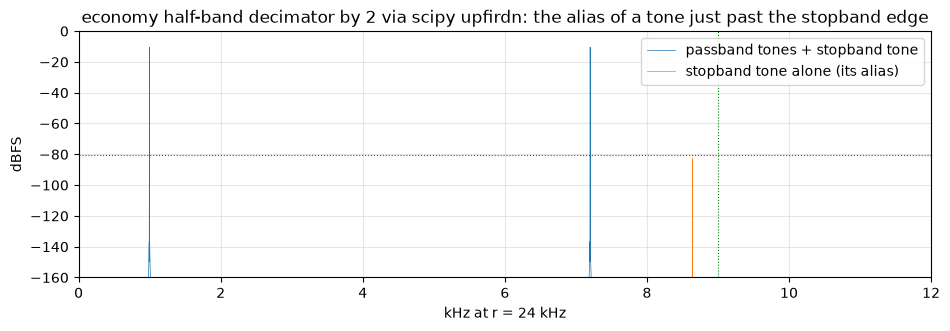

In [5]:
h, m, atten, p = designs[(2, "economy")]
band = 2
fs_in = 48000.0            # the stage's higher rate
r = fs_in / band           # the lower rate, 24 kHz
n_in = 1 << 16
n_out = n_in // band - len(h)
df = r / n_out             # the analysis bin
def on_bin(f0):
    return round(f0 / df) * df
t = np.arange(n_in) / fs_in
tones = [(on_bin(997.0), 0.30), (on_bin(0.30 * r), 0.30)]   # in the passband (f_pass = 0.375 r)
stop_tone = (on_bin(0.64 * r), 0.30)                        # just above r - f_pass = 0.625 r; folds to 0.36 r
x = sum(a * np.sin(2 * np.pi * f0 * t) for f0, a in tones)
x_stop = stop_tone[1] * np.sin(2 * np.pi * stop_tone[0] * t)

def spectrum(sig):
    y = signal.upfirdn(h / band, sig, up=1, down=band)[len(h) // (2 * band):][:n_out]
    win = np.blackman(len(y))
    spec = np.abs(np.fft.rfft(y * win)) / (win.sum() / 2)
    return np.fft.rfftfreq(len(y), 1 / r), 20 * np.log10(np.maximum(spec, 1e-12))

fbin, db = spectrum(x + x_stop)
fbin, db_stop = spectrum(x_stop)
def level_near(d, f0, width=3 * df):
    return d[np.abs(fbin - f0) <= width].max()
full = 20 * np.log10(0.30)
for f0, _ in tones:
    print(f"passband tone at {f0:8.1f} Hz: {level_near(db, f0):8.3f} dBFS (source {full:.3f}; ripple <= 0.0022 dB)")
    assert abs(level_near(db, f0) - full) < 0.01
alias_f = r - stop_tone[0]
alias_rel = level_near(db_stop, alias_f) - full
print(f"stopband tone at {stop_tone[0]:7.1f} Hz aliases to {alias_f:7.1f} Hz at {alias_rel:8.2f} dB (spec -{atten:.0f} dB, margin 1 dB)")
assert alias_rel <= -(atten + 1.0)
mask = (fbin > 200) & ~(np.abs(fbin - tones[0][0]) <= 3 * df) & ~(np.abs(fbin - tones[1][0]) <= 3 * df) & ~(np.abs(fbin - alias_f) <= 3 * df)
print(f"worst other spur      : {db[mask].max():8.1f} dBFS")
assert db[mask].max() < -100.0

plt.figure(figsize=(11, 3.2))
plt.plot(fbin / 1e3, db, lw=0.5, label="passband tones + stopband tone")
plt.plot(fbin / 1e3, db_stop, lw=0.5, label="stopband tone alone (its alias)")
plt.axhline(full - atten, color='r', ls=':', lw=0.8)
plt.axvline(p * r / 1e3, color='g', ls=':', lw=0.8)
plt.ylim(-160, 0); plt.xlim(0, r / 2e3); plt.legend(loc="upper right")
plt.title("economy half-band decimator by 2 via scipy upfirdn: the alias of a tone just past the stopband edge")
plt.xlabel("kHz at r = 24 kHz"); plt.ylabel("dBFS"); plt.grid(alpha=0.3)
plt.show()


## Pinned numbers (committed to PLAN.md §6, the M2 table)

The N column per band × profile above is the table; `tests/test_design.cpp`
pins every row against `design_stage<R>` (the shipping designer) with the
same grid, the same minimality check and the ripple bound of §2.3
(±0.01 dB per 70 dB stage, ±0.0001 dB per `transparent` stage — measured
±0.0025 and ±0.00001). Two rows differ from a 1024-point search: band 4
`balanced` (111, not 103) and band 8 `transparent` (399, not 383), the
sidelobes the coarse grid steps over; the half- and third-band rows are the
v0.3 numbers unchanged.
